In [15]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

## 1 . Loading and Inspecting of Data

In [2]:
## loading the dataset into our environment

In [3]:
path="healthcare-dataset-stroke-data.csv"
stroke_prediction_df=pd.read_csv(path)
stroke_prediction_df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [4]:
## inspecting the dataset

#### 1. First and Last few rows

In [5]:
stroke_prediction_df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [6]:
stroke_prediction_df.tail()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0
5109,44679,Female,44.0,0,0,Yes,Govt_job,Urban,85.28,26.2,Unknown,0


#### 2. Information of dataset

In [7]:
stroke_prediction_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


#### 3. Shape of dataset

In [8]:
stroke_prediction_df.shape

(5110, 12)

#### 4. Columns in dataset 

In [9]:
stroke_prediction_df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

#### 5. Summary Statistics (Numerical columns)

In [10]:
stroke_prediction_df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


 #### 6. Checking missing values

In [11]:
stroke_prediction_df.isna().sum()/len(stroke_prediction_df)

id                   0.000000
gender               0.000000
age                  0.000000
hypertension         0.000000
heart_disease        0.000000
ever_married         0.000000
work_type            0.000000
Residence_type       0.000000
avg_glucose_level    0.000000
bmi                  0.039335
smoking_status       0.000000
stroke               0.000000
dtype: float64

#### Observation :
#### 1. The bmi column contains missing values
#### 2. Our target variable = stroke

## 2: Visualizations & Analysis

#### 2.1 Analyze the Target Variable (stroke)

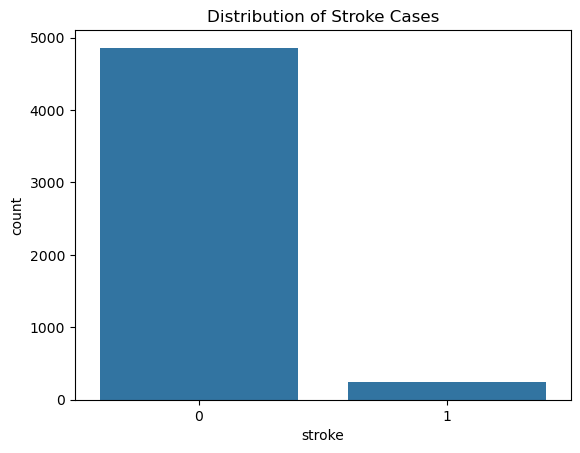

stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


In [16]:
sns.countplot(x="stroke", data=stroke_prediction_df)
plt.title("Distribution of Stroke Cases")
plt.show()

print(stroke_prediction_df["stroke"].value_counts(normalize=True) * 100)

Usually, stroke cases are much fewer than non-stroke → class imbalance.

#### 2.2 Visualize Numerical Features

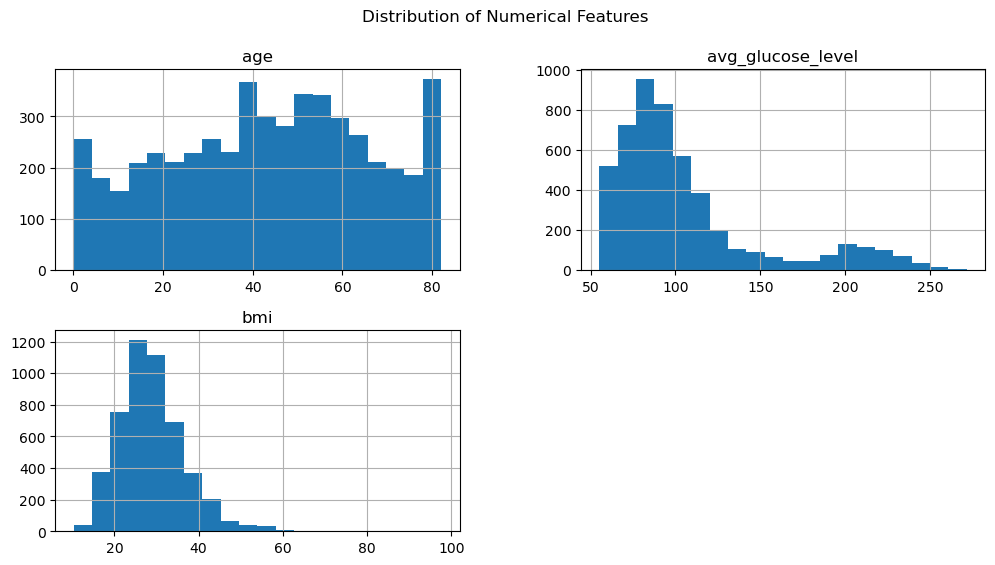

In [17]:
numerical_features = ['age', 'avg_glucose_level', 'bmi']

stroke_prediction_df[numerical_features].hist(figsize=(12,6), bins=20)
plt.suptitle("Distribution of Numerical Features")
plt.show()



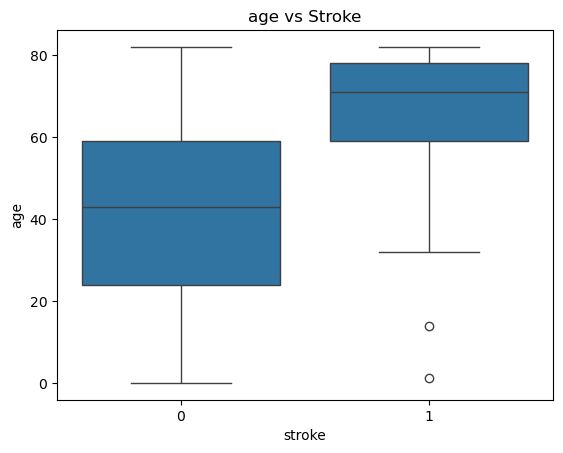

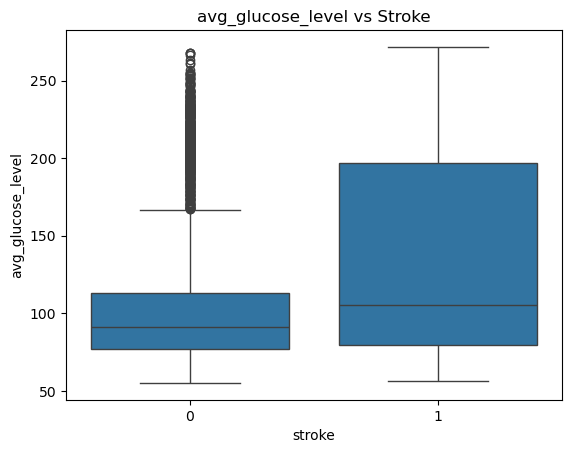

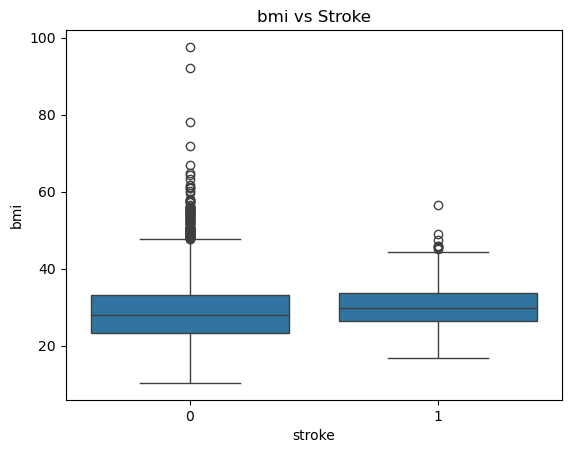

In [18]:
for col in numerical_features:
    sns.boxplot(x='stroke', y=col, data=stroke_prediction_df)
    plt.title(f"{col} vs Stroke")
    plt.show()

Observation: 
1. Age : Most stroke cases occur in older patients, generally above 50–60 years.
2. Average Glucose Level : Patients with strokes tend to have higher glucose levels.
3. BMI : Patients with strokes generally have higher BMI.

#### 2.3 Visualize Categorical Features

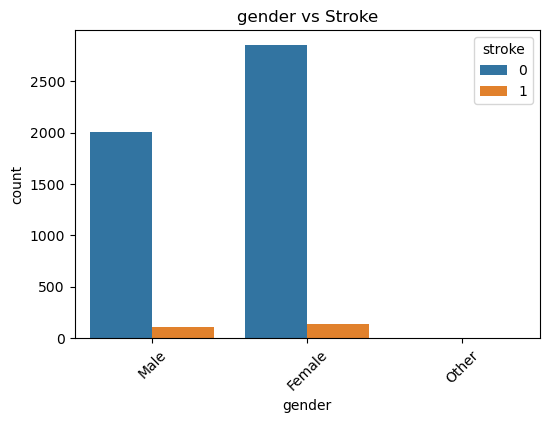

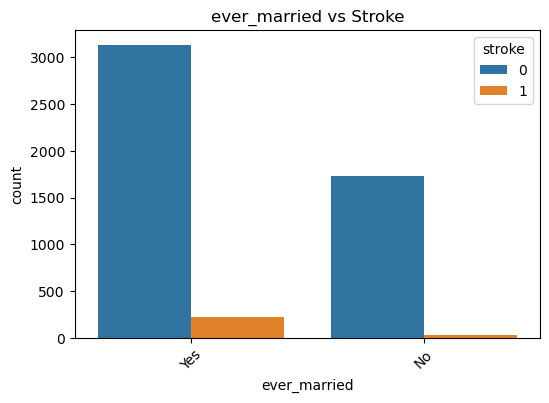

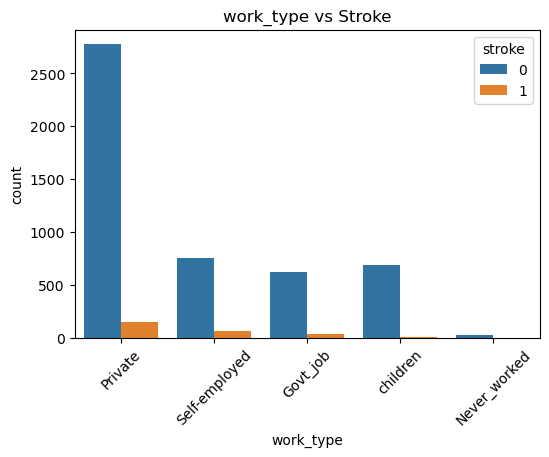

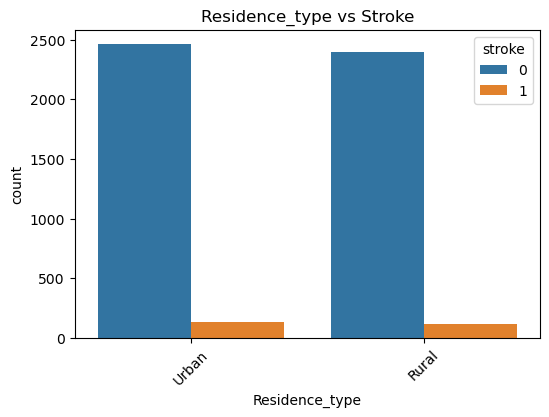

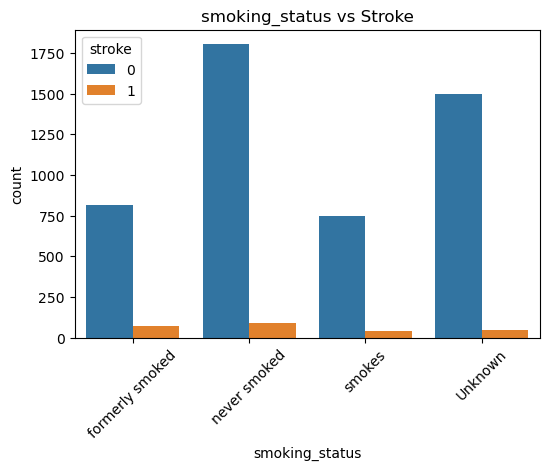

In [19]:
categorical_features = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

for col in categorical_features:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='stroke', data=stroke_prediction_df)
    plt.title(f"{col} vs Stroke")
    plt.xticks(rotation=45)
    plt.show()

Observation :

1. Gender : Both males and females are represented, but stroke cases appear slightly higher among females (common in this dataset).
2. Ever Married : Most stroke cases occur in married patients (probably because they are older on average).
3. Work Type : Private and Self-employed groups have the majority of stroke cases (as they also represent the largest population).
4. Residence Type : No strong difference — urban vs rural stroke occurrence is roughly similar.
5. Smoking Status : Stroke cases are more common among formerly smoked or smokes groups.

## 3. Identification and handling of missing values.

In [20]:
# Check missing values

In [21]:
print(stroke_prediction_df.isnull().sum())

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


In [22]:
## handling missing values ::  by substituing median in place od missing values

In [23]:
stroke_prediction_df['bmi'].fillna(stroke_prediction_df['bmi'].median(), inplace=True)
print(stroke_prediction_df.isnull().sum())

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


## 4.	Encoding of categorical variables.

####  Encoding Approaches:
Label Encoding for binary features (gender, ever_married):

In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
binary_cols = ['gender', 'ever_married']
for col in binary_cols:
    stroke_prediction_df[col] = le.fit_transform(stroke_prediction_df[col])

One-Hot Encoding for features with multiple categories (work_type, Residence_type, smoking_status):

In [25]:
stroke_prediction_df = pd.get_dummies(stroke_prediction_df, columns=['work_type', 'Residence_type', 'smoking_status'], drop_first=True)

## 5. Data Scaling or Normalization 

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = ['age', 'avg_glucose_level', 'bmi']
stroke_prediction_df[num_cols] = scaler.fit_transform(stroke_prediction_df[num_cols])

In [28]:
print(stroke_prediction_df[['age', 'avg_glucose_level', 'bmi']].head())

        age  avg_glucose_level       bmi
0  1.051434           2.706375  1.005086
1  0.786070           2.121559 -0.098981
2  1.626390          -0.005028  0.472536
3  0.255342           1.437358  0.719327
4  1.582163           1.501184 -0.631531
